# Exercise 7
**Cristina Correa - 1819211867**


In this exercise we will use the A* to find the most optimal path in a graph:

```
     A--------1--------B
      \                /
       \              5
        \            /     
  F------\---3------D
  |       2        /
  |        \      2
  2         \    /
  |          \  /
  E-----4---- C
```



In [10]:
import heapq
import matplotlib.pyplot as plt
import networkx as nx

# Class representing a node in the graph
class Node:
    def __init__(self, name, heuristic_cost):
        self.name = name
        self.heuristic_cost = heuristic_cost
        self.adjacent = {}
        self.parent = None
        self.g_cost = float("inf")

    def add_neighbor(self, neighbor, cost):
        self.adjacent[neighbor] = cost

    def __lt__(self, other):
        return self.g_cost + self.heuristic_cost < other.g_cost + other.heuristic_cost

In [11]:
# A* search algorithm
def astar_search(start, goal):
    open_list = []
    closed_set = set()
    start.g_cost = 0
    heapq.heappush(open_list, start)

    while open_list:
        current_node = heapq.heappop(open_list)

        if current_node == goal:
            path = []
            while current_node is not None:
                path.append(current_node.name)
                current_node = current_node.parent
            return path[::-1]

        closed_set.add(current_node)

        for neighbor, cost in current_node.adjacent.items():
            tentative_g_cost = current_node.g_cost + cost

            if neighbor in closed_set and tentative_g_cost >= neighbor.g_cost:
                continue

            if tentative_g_cost < neighbor.g_cost or neighbor not in open_list:
                neighbor.g_cost = tentative_g_cost
                neighbor.parent = current_node
                if neighbor not in open_list:
                    heapq.heappush(open_list, neighbor)
    return None

In [12]:
# Creating nodes
A = Node("A", 5)
B = Node("B", 4)
C = Node("C", 3)
D = Node("D", 2)
E = Node("E", 1)
F = Node("F", 0)

# Adding neighbors and their costs
A.add_neighbor(B, 1)
A.add_neighbor(C, 2)
B.add_neighbor(D, 5)
C.add_neighbor(D, 2)
C.add_neighbor(E, 4)
D.add_neighbor(F, 3)
E.add_neighbor(F, 2)

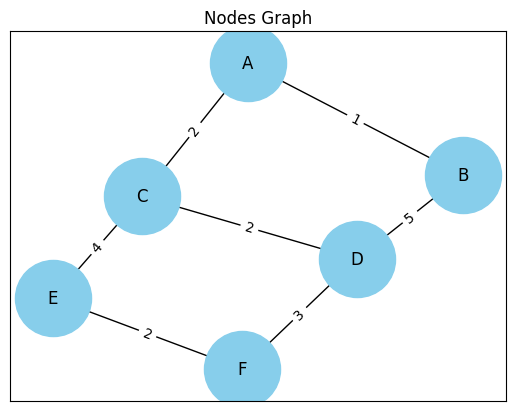

In [28]:
# Visualization without the solution
G = nx.Graph()
edges = [
    (A.name, B.name, {"weight": 1}),
    (A.name, C.name, {"weight": 2}),
    (B.name, D.name, {"weight": 5}),
    (C.name, D.name, {"weight": 2}),
    (C.name, E.name, {"weight": 4}),
    (D.name, F.name, {"weight": 3}),
    (E.name, F.name, {"weight": 2}),
]
G.add_edges_from(edges)

pos = nx.spring_layout(G)
nx.draw_networkx(G, pos, with_labels=True, node_size=3000, node_color="skyblue")
labels = nx.get_edge_attributes(G, "weight")
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)

plt.title("Nodes Graph")
plt.show()

In [29]:
path = astar_search(A, F)
print("A* path:", path)

A* path: ['A', 'C', 'D', 'F']


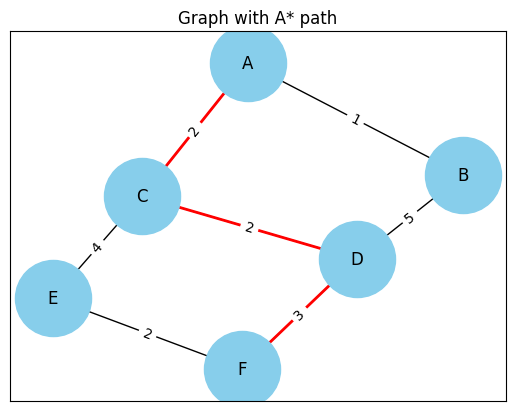

In [30]:
# Visualisation with A* path
plt.title("Graph with A* path")
nx.draw_networkx(G, pos, with_labels=True, node_size=3000, node_color="skyblue")
nx.draw_networkx_edges(
    G,
    pos,
    edgelist=[(path[i], path[i + 1]) for i in range(len(path) - 1)],
    edge_color="r",
    width=2,
)
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels)
plt.show()